In [1]:
import app
import datetime
import json
import os.path

import pandas as pd
import requests

import matplotlib.pyplot as plt
import numpy as np

Import data

In [3]:
ecoli_timeseries_dfs = app.get_ecoli_datasets()

Plot e-coli time series

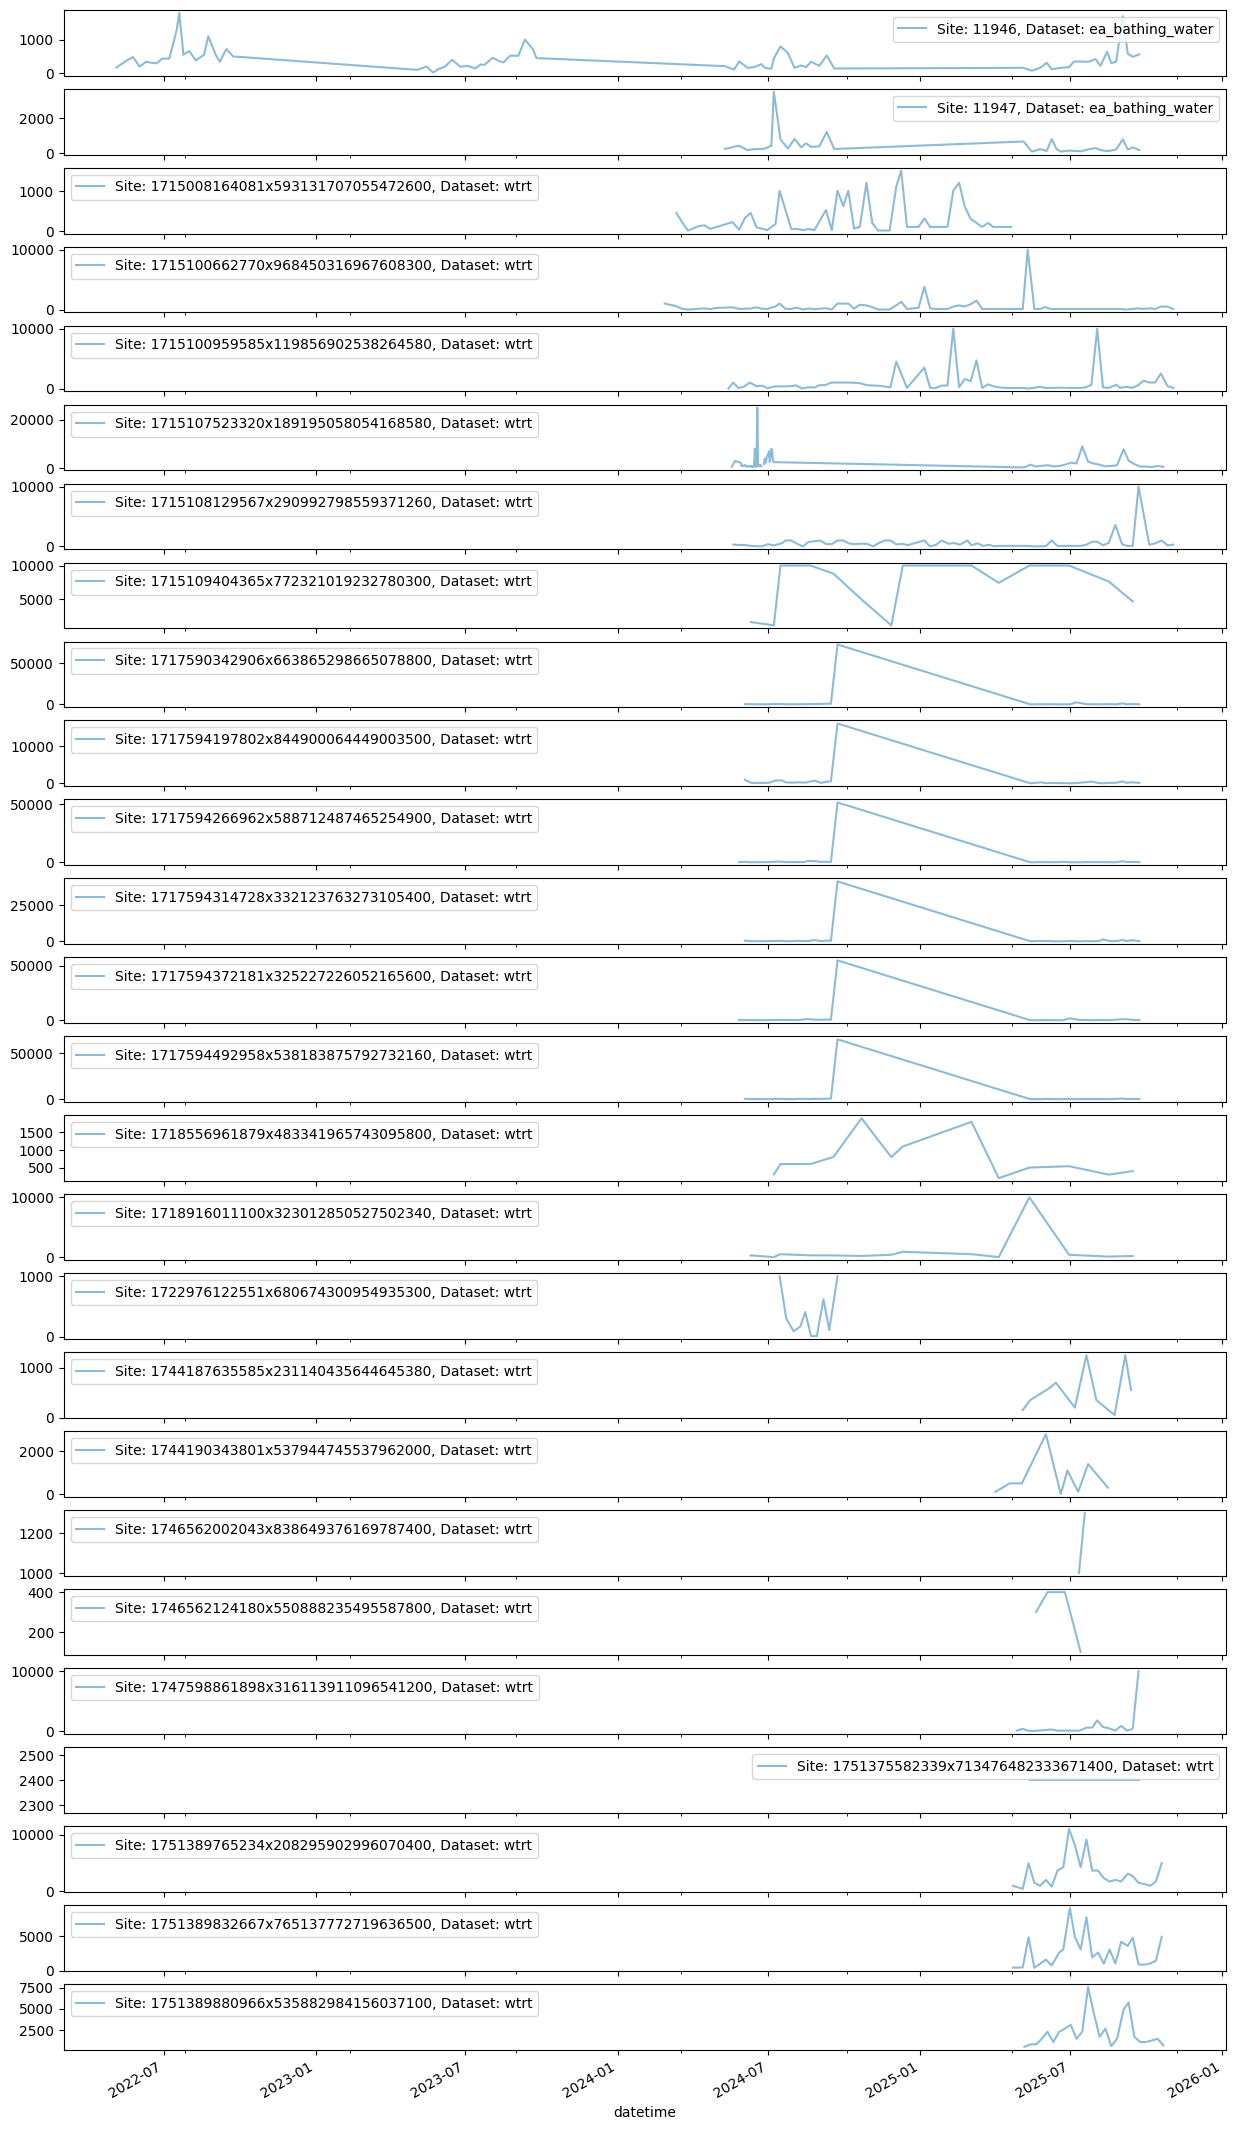

In [4]:
no_dfs = len(ecoli_timeseries_dfs)

fig, ax = plt.subplots(no_dfs, figsize=(15, 30), sharex=True)

#properly align dates, fill missing dates with NaN, deal with multiple measurements in a day
dates_complete = pd.date_range(start='2022-01-01', end='2025-11-01', freq='D')

for i, (df, key) in enumerate(zip(ecoli_timeseries_dfs.values(), ecoli_timeseries_dfs.keys())):
    df['datetime'] = df['datetime'].dt.floor('D') # Keep date only, ignore time of measurement
    df = df.groupby('datetime').first().reset_index() #in case of multiple measurements in a day, take first
    #df = df.set_index('datetime').reindex(dates_complete).reset_index().rename(columns={'index': 'datetime'})
    df.plot(x='datetime', y='escherichia coli count', ax=ax[i], legend=False, alpha=0.5, label = f'Site: {key[0]}, Dataset: {key[1]}')
    ax[i].legend()